In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
X = np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg = np.array([30, 40, 45, 55, 65, 70, 80, 90])
y_cls = np.array([ 0, 0, 0, 0, 1, 1, 1, 1])
lin = LinearRegression()
lin.fit(X, y_reg)
print('Regression output:', lin.predict([[5.5]]))
log = LogisticRegression()
log.fit(X, y_cls)
print('Classification output:', log.predict([[5.5]]))

print('Probability output :', log.predict_proba([[5.5]]))

Regression output: [67.76785714]
Classification output: [1]
Probability output : [[0.2368932 0.7631068]]


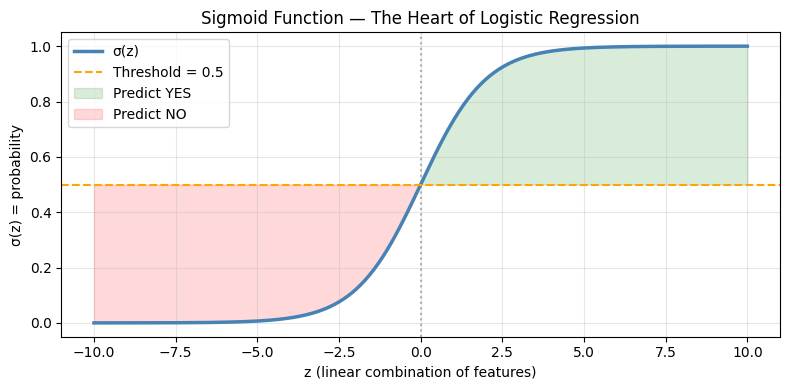

sigmoid(0) = 0.5000
sigmoid(5) = 0.9933
sigmoid(-5) = 0.0067


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)

prob = sigmoid(z)
plt.figure(figsize=(8, 4))
plt.plot(z, prob, color='steelblue', linewidth=2.5, label='σ(z)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.6)
plt.fill_between(z, prob, 0.5, where=(prob > 0.5), alpha=0.15, color='green', label='Predict YES')
plt.fill_between(z, prob, 0.5, where=(prob < 0.5), alpha=0.15, color='red', label='Predict NO')
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) = probability')
plt.title('Sigmoid Function — The Heart of Logistic Regression')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'sigmoid(0) = {sigmoid(0):.4f}')
print(f'sigmoid(5) = {sigmoid(5):.4f}')
print(f'sigmoid(-5) = {sigmoid(-5):.4f}')

In [6]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=500, n_features=5,
                        weights=[0.7, 0.3],
                        random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression();
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]

print(f'{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>6}')
print('-' * 45)
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (probs >= threshold).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds, zero_division=0)
    print(f'{threshold:>10.1f} {p:>10.3f} {r:>8.3f} {f:>6.3f}')

 Threshold  Precision   Recall     F1
---------------------------------------------
       0.2      0.696    0.941  0.800
       0.3      0.762    0.941  0.842
       0.4      0.882    0.882  0.882
       0.5      0.882    0.882  0.882
       0.6      0.903    0.824  0.862
       0.7      0.903    0.824  0.862
       0.8      0.958    0.676  0.793


TP=5, TN=4, FP=3, FN=3
Accuracy = (TP+TN)/Total = (5+4)/15 = 60.00%
Precision = TP/(TP+FP) = 5/8 = 62.50%
Recall = TP/(TP+FN) = 5/8 = 62.50%
Confusion matrix:
 [[4 3]
 [3 5]]


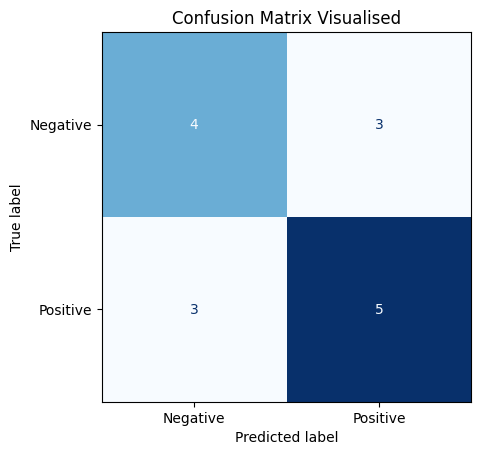

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = [1,1,1,1,1, 0,0,0,0,0, 1,0,1,0,1]
y_pred = [1,1,1,0,0, 0,0,0,1,1, 1,0,0,1,1]

y_true = np.array(y_true)
y_pred = np.array(y_pred)
TP = ((y_pred == 1) & (y_true == 1)).sum()
TN = ((y_pred == 0) & (y_true == 0)).sum()
FP = ((y_pred == 1) & (y_true == 0)).sum()
FN = ((y_pred == 0) & (y_true == 1)).sum()

print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')
print(f'Accuracy = (TP+TN)/Total = ({TP}+{TN})/{len(y_true)} = {(TP+TN)/len(y_true):.2%}')
print(f'Precision = TP/(TP+FP) = {TP}/{TP+FP} = {TP/(TP+FP):.2%}')
print(f'Recall = TP/(TP+FN) = {TP}/{TP+FN} = {TP/(TP+FN):.2%}')

cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:\n', cm)

disp = ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix Visualised'); plt.show()

In [8]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
X_bal, y_bal = make_classification(n_samples=1000, weights=[0.5, 0.5], random_state=1)
X_imb, y_imb = make_classification(n_samples=1000, weights=[0.99, 0.01], random_state=1)
def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f'\n=== {label} ===')
    print(f'Accuracy : {acc:.2%} ← {'MISLEADING!' if f1 < 0.5 else 'OK'}')
    print(f'F1 Score : {f1:.2%} ← Real performance')
    print(classification_report(y_test, y_pred, zero_division=0))
evaluate(X_bal, y_bal,'balanced data')
evaluate(X_imb, y_imb,'imbalanced data')
X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)

model_fixed = LogisticRegression(class_weight='balanced', max_iter=1000)

model_fixed.fit(X_train, y_train)

y_pred_fixed = model_fixed.predict(X_test)

print('\n=== After class_weight=balanced ===')
print(classification_report(y_test, y_pred_fixed, zero_division=0))


=== balanced data ===
Accuracy : 80.50% ← OK
F1 Score : 80.00% ← Real performance
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       106
           1       0.77      0.83      0.80        94

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.81       200


=== imbalanced data ===
Accuracy : 97.50% ← MISLEADING!
F1 Score : 0.00% ← Real performance
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200


=== After class_weight=balanced ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       196
           1       0.04 

In [9]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=800, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
lr = LogisticRegression().fit(X_train, y_train)
prob_lr = lr.predict_proba(X_test)[:, 1]

In [11]:
dt = DecisionTreeClassifier(max_depth=4).fit(X_train, y_train)
prob_dt = dt.predict_proba(X_test)[:, 1]

In [12]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
auc_lr = roc_auc_score(y_test, prob_lr)
auc_dt = roc_auc_score(y_test, prob_dt)

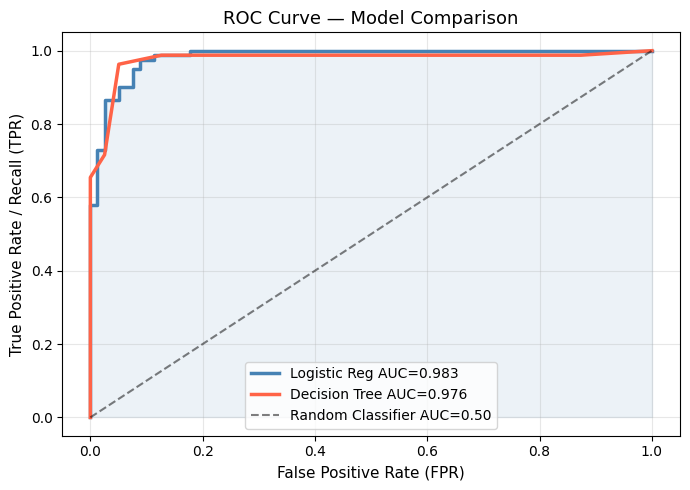

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, lw=2.5, color='steelblue', label=f'Logistic Reg AUC={auc_lr:.3f}')
plt.plot(fpr_dt, tpr_dt, lw=2.5, color='tomato', label=f'Decision Tree AUC={auc_dt:.3f}')
plt.plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier AUC=0.50')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=11)
plt.title('ROC Curve — Model Comparison', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [14]:
print(f'Logistic Regression AUC: {auc_lr:.4f}')
print(f'Decision Tree AUC: {auc_dt:.4f}')
print('Higher AUC = better model at separating classes')

Logistic Regression AUC: 0.9833
Decision Tree AUC: 0.9761
Higher AUC = better model at separating classes


--2026-06-17 08:16:41--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0.005s  

2026-06-17 08:16:41 (4.54 MB/s) - ‘diabetes.csv’ saved [23873/23873]

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00       

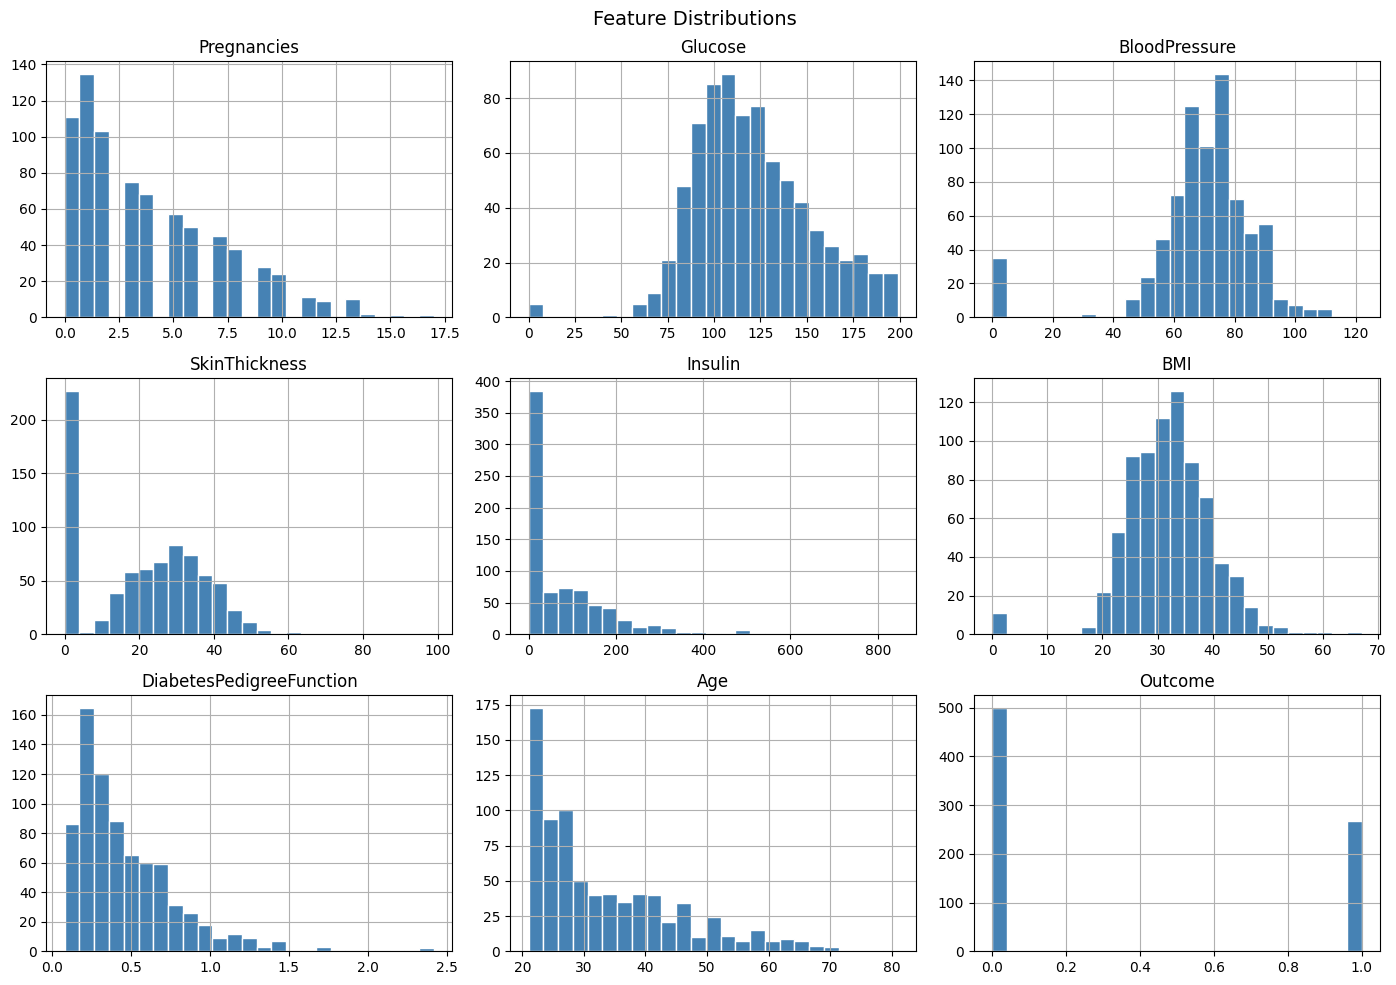

In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

!test -f diabetes.csv || wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
print(df.shape)
print(df['Outcome'].value_counts())
print(df.describe().round(2))
df.hist(bins=25, figsize=(14,10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()

In [16]:
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f'{col:25s}: {n} zeros → replaced with median {df[col].median():.1f}')

Glucose                  : 5 zeros → replaced with median 117.0
BloodPressure            : 35 zeros → replaced with median 72.0
SkinThickness            : 227 zeros → replaced with median 23.0
Insulin                  : 374 zeros → replaced with median 31.2
BMI                      : 11 zeros → replaced with median 32.0


In [17]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
for name, coef in zip(X.columns, model.coef_[0]):
    print(f'{name:30s}: {coef:+.3f}')

Pregnancies                   : +0.376
Glucose                       : +1.209
BloodPressure                 : -0.054
SkinThickness                 : +0.029
Insulin                       : -0.133
BMI                           : +0.701
DiabetesPedigreeFunction      : +0.245
Age                           : +0.138


              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



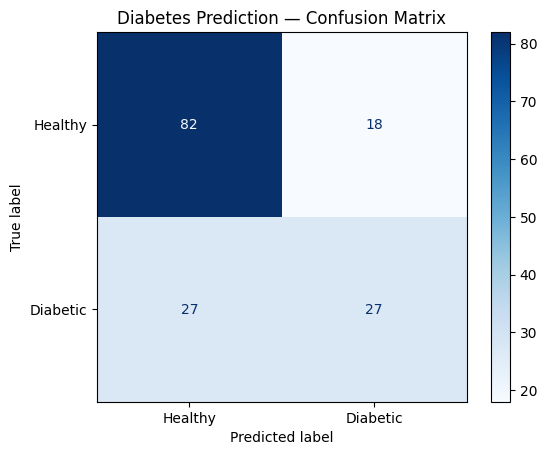

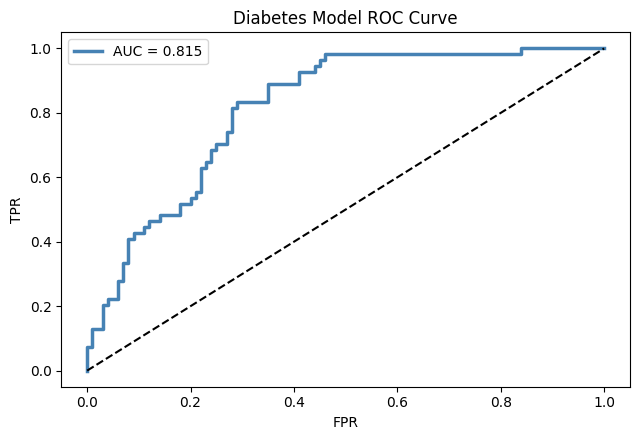

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(cmap='Blues')
plt.title('Diabetes Prediction — Confusion Matrix'); plt.show()
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6.5, 4.5))
plt.plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Diabetes Model ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Prediction : Diabetic
Probability : 73.4% chance of having diabetes


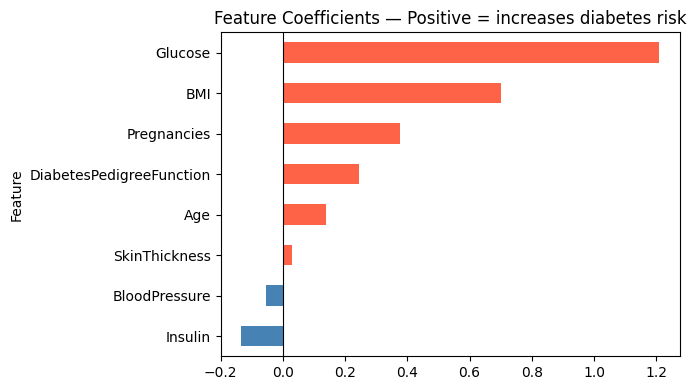

In [19]:
new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
new_scaled = scaler.transform(new_patient)
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]
print(f'Prediction : {'Diabetic' if pred==1 else 'Healthy'}')
print(f'Probability : {prob:.1%} chance of having diabetes')
import pandas as pd
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color=['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']],
legend=False, figsize=(7, 4))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Positive = increases diabetes risk')
plt.tight_layout(); plt.show()